<a href="https://colab.research.google.com/github/divyasri-jonnadula-16/spoken-language-identification/blob/main/CNN_BiLSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torchaudio librosa tqdm scikit-learn


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
DATASET_ROOT = "/content/drive/MyDrive/spokenvoice"

TRAIN_PATH = DATASET_ROOT + "/train"
TEST_PATH = DATASET_ROOT + "/test"


In [ ]:
import os
import torch
import torchaudio
from torch.utils.data import Dataset

class LanguageDataset(Dataset):
    def __init__(self, root_dir, sample_rate=16000, max_len=5):
        self.files = []
        self.labels = []
        self.sample_rate = sample_rate
        self.max_len = sample_rate * max_len

        languages = sorted(os.listdir(root_dir))
        self.label_map = {lang:i for i, lang in enumerate(languages)}

        for lang in languages:
            lang_path = os.path.join(root_dir, lang)
            for file in os.listdir(lang_path):
                if file.endswith(".flac"):
                    self.files.append(os.path.join(lang_path, file))
                    self.labels.append(self.label_map[lang])

        self.mel = torchaudio.transforms.MelSpectrogram(
            sample_rate=sample_rate,
            n_mels=128
        )

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        audio, sr = torchaudio.load(self.files[idx])

        if sr != self.sample_rate:
            audio = torchaudio.functional.resample(audio, sr, self.sample_rate)

        audio = audio.mean(dim=0)

        if len(audio) > self.max_len:
            audio = audio[:self.max_len]
        else:
            audio = torch.nn.functional.pad(audio, (0, self.max_len - len(audio)))

        mel_spec = self.mel(audio)
        mel_spec = torch.log(mel_spec + 1e-9)

        return mel_spec.unsqueeze(0), self.labels[idx]


In [ ]:
train_dataset = LanguageDataset(TRAIN_PATH)
test_dataset = LanguageDataset(TEST_PATH)


/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:582: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


In [ ]:
from torch.utils.data import random_split

train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_ds, val_ds = random_split(train_dataset, [train_size, val_size])


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)


In [ ]:
import torch
import torch.nn as nn

class CNN_BiLSTM(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        # CNN Feature Extractor
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # BiLSTM
        self.lstm = nn.LSTM(
            input_size=64*32,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )

        # Classifier
        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.cnn(x)

        b, c, f, t = x.shape

        # reshape for LSTM
        x = x.permute(0, 3, 1, 2).contiguous().view(b, t, c*f)

        x, _ = self.lstm(x)

        x = x[:, -1, :]  # last timestep

        return self.fc(x)


In [ ]:
device = torch.device("cpu")

model = CNN_BiLSTM(num_classes=3).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [ ]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score

def train_epoch(loader):
    model.train()
    total_loss = 0

    for x, y in tqdm(loader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def evaluate(loader):
    model.eval()
    preds = []
    targets = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            outputs = model(x)
            preds.extend(outputs.argmax(1).cpu().numpy())
            targets.extend(y.numpy())

    return accuracy_score(targets, preds)


In [ ]:
EPOCHS = 15

for epoch in range(EPOCHS):
    loss = train_epoch(train_loader)
    val_acc = evaluate(val_loader)

    print(f"Epoch {epoch+1} | Loss {loss:.4f} | Val Acc {val_acc:.4f}")


100%|██████████| 338/338 [33:07<00:00,  5.88s/it]


Epoch 1 | Loss 0.9565 | Val Acc 0.6600


100%|██████████| 338/338 [18:49<00:00,  3.34s/it]


Epoch 2 | Loss 0.5315 | Val Acc 0.8567


100%|██████████| 338/338 [20:48<00:00,  3.69s/it]


...

Epoch 13 | Loss 0.0504 | Val Acc 0.9917


100%|██████████| 338/338 [24:23<00:00,  4.33s/it]


Epoch 14 | Loss 0.0614 | Val Acc 0.9817


100%|██████████| 338/338 [24:57<00:00,  4.43s/it]


Epoch 15 | Loss 0.0464 | Val Acc 0.9850


In [ ]:
test_acc = evaluate(test_loader)
print("Final Test Accuracy:", test_acc)


Final Test Accuracy: 0.7314814814814815


In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/language_id_model.pth")


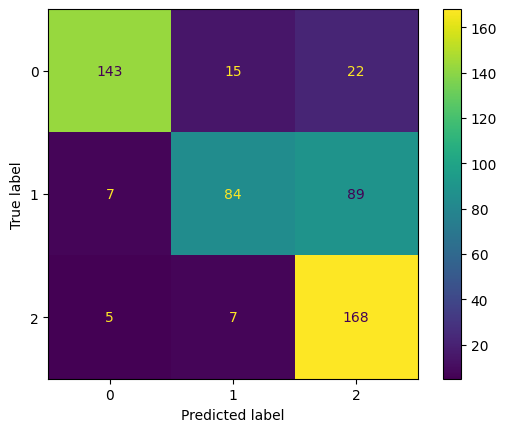

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()
preds = []
targets = []

with torch.no_grad():
    for x, y in test_loader:
        outputs = model(x)
        preds.extend(outputs.argmax(1).numpy())
        targets.extend(y.numpy())

cm = confusion_matrix(targets, preds)
ConfusionMatrixDisplay(cm).plot()
plt.show()


In [ ]:
test_acc = evaluate(test_loader)
print("Test Accuracy:", test_acc)


Test Accuracy: 0.7314814814814815


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(targets, preds, target_names=["english","german","spanish"]))


              precision    recall  f1-score   support

     english       0.92      0.79      0.85       180
      german       0.79      0.47      0.59       180
     spanish       0.60      0.93      0.73       180

    accuracy                           0.73       540
   macro avg       0.77      0.73      0.72       540
weighted avg       0.77      0.73      0.72       540

